# Random Forest Regresija — Predikcija Cena Automobila
### Pipeline ovog notebook-a
| Korak | Sadržaj                                                   |
|---|-----------------------------------------------------------|
| 1 | Uvoz biblioteka + učitavanje podataka                     |
| 2 | Definisanje feature-a + Train/Test split                  |
| 3 | Sklearn Pipeline (ColumnTransformer + RF)                 |
| 4 | Hyperparameter tuning (RandomizedSearchCV → GridSearchCV) |
| 5 | Evaluacija: train vs test, sve metrike                    |
| 6 | Vizualizacije: Predicted vs Actual, Residuali             |
| 7 | Feature Importance (Top 10)                               |
| 8 | Cross-Validation Score                                    |
| 9 | Poređenje sa Ridge modelom                                |
| 10 | Napomena o PCA                                            |
| 11 | Finalni zaključak                                         |



## Korak 1: Uvoz biblioteka i učitavanje dataseta

Koristimo `sklearn.preprocessing.TargetEncoder` (sklearn ≥ 1.3) koji je direktno integrisan  
u `Pipeline` i eliminiše data leakage koji nastaje kada se encoding radi pre CV-a.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import joblib
import os
import time
from pathlib import Path

# Sklearn — core
from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV, GridSearchCV,
    cross_val_score, KFold
)
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, TargetEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Scipy za distribucije u RandomizedSearchCV
from scipy.stats import randint, uniform

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

# ── Učitavanje podataka ───────────────────────────────────────────────────────
BASE_DIR       = Path.cwd()
PROCESSED_DIR  = BASE_DIR.parent / 'DataSet' / 'processed'
DATA_PATH      = PROCESSED_DIR / 'procesirani_podaci.csv'

df = pd.read_csv(DATA_PATH)

print(f'Dataset shape:  {df.shape}')
print(f'Kolone:         {list(df.columns)}')
print(f'Nedostajuće:    {df.isnull().sum().sum()}')
df.head(3)


Dataset shape:  (239844, 13)
Kolone:         ['brand', 'model', 'color', 'year', 'price_in_euro', 'power_kw', 'transmission_type', 'fuel_type', 'fuel_consumption_l_100km', 'fuel_consumption_g_km', 'mileage_in_km', 'registration_month', 'car_age']
Nedostajuće:    0


,brand,model,color,year,price_in_euro,power_kw,transmission_type,fuel_type,fuel_consumption_l_100km,fuel_consumption_g_km,mileage_in_km,registration_month,car_age
0,alfa-romeo,alfa romeo gtv,red,1995.0,1300.0,148.0,manual,petrol,10.9,260.0,160500.0,10.0,31.0
1,alfa-romeo,alfa romeo 164,black,1995.0,24900.0,191.0,manual,petrol,5.7,135.0,190000.0,2.0,31.0
2,alfa-romeo,alfa romeo spider,black,1995.0,4900.0,110.0,manual,petrol,9.5,225.0,189500.0,7.0,31.0


## Korak 2: Definisanje feature-a + Train/Test Split

**Važna napomena o strategiji:**
Encoding (TargetEncoder, OneHotEncoder) je definisan kao deo Pipeline-a i biće  
primenjen **unutar svakog CV folda** — čime se eliminiše data leakage.

Kolone se grupišu po tipu da bi ih `ColumnTransformer` pravilno obradio:
- `target_enc_cols` — visoka kardinalnost → **TargetEncoder** (fit samo na train foldu)
- `ohe_cols`        — niska kardinalnost  → **OneHotEncoder**
- `numeric_cols`    — numeričke vrednosti → **passthrough** (RF ne zahteva skaliranje)


In [2]:
# ── Definisanje ciljne promenljive ───────────────────────────────────────────
TARGET = 'price_in_euro'

# ── Grupisanje kolona po tipu encodinga ──────────────────────────────────────
target_enc_cols = ['brand', 'model']                      # visoka kardinalnost
ohe_cols        = ['transmission_type', 'fuel_type', 'color']  # niska kardinalnost

all_cat_cols = target_enc_cols + ohe_cols
numeric_cols = [c for c in df.columns
                if c != TARGET and c not in all_cat_cols]

print('Feature grupe:')
print(f'  TargetEncoder  : {target_enc_cols}')
print(f'  OneHotEncoder  : {ohe_cols}')
print(f'  Passthrough    : {numeric_cols}')

X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'\nX_train: {X_train.shape}  |  X_test: {X_test.shape}')
print(f'y range: [{y.min():,.0f} EUR, {y.max():,.0f} EUR]  |  mean: {y.mean():,.0f} EUR')


Feature grupe:
  TargetEncoder  : ['brand', 'model']
  OneHotEncoder  : ['transmission_type', 'fuel_type', 'color']
  Passthrough    : ['year', 'power_kw', 'fuel_consumption_l_100km', 'fuel_consumption_g_km', 'mileage_in_km', 'registration_month', 'car_age']

X_train: (191875, 12)  |  X_test: (47969, 12)
y range: [500 EUR, 300,000 EUR]  |  mean: 24,936 EUR


## Korak 3: Sklearn ML Pipeline

### Zašto Pipeline umesto ručnog encodinga?

| Pristup | Problem |
|---|---|
| Encoding pre splita | **DATA LEAKAGE** — test info curi u train |
| Encoding posle splita, pre CV | **LEAKAGE** — val fold info curi u encoding |
| Encoding unutar Pipeline-a | svaki fold ima sopstveni encoder |



In [3]:
# ── Preprocessing layer ───────────────────────────────────────────────────────
preprocessor = ColumnTransformer(
    transformers=[
        ('target_enc',
         TargetEncoder(target_type='continuous', smooth='auto'),
         target_enc_cols),

        ('ohe',
         OneHotEncoder(handle_unknown='ignore', sparse_output=False),
         ohe_cols),

        ('passthrough',
         'passthrough',
         numeric_cols),
    ],
    remainder='drop',
    verbose_feature_names_out=True,
)

# ── Full Pipeline ─────────────────────────────────────────────────────────────
pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestRegressor(random_state=42, n_jobs=-1))
])

# ── Sanity check: pipeline se fituje na train skupu ──────────────────────────
print('Pipeline definisan. Provera fit/predict...')
_t = time.time()
pipeline.fit(X_train, y_train)
print(f'  Fit OK  ({time.time()-_t:.1f}s)')

_score = r2_score(y_test, pipeline.predict(X_test))
print(f'  Default parametri → R² (test): {_score:.4f}')

# ── Prikaz feature dimenzija nakon preprocessinga ────────────────────────────
n_features_out = pipeline.named_steps['preprocess'].transform(X_train[:5]).shape[1]
print(f'\nBroj feature-a posle preprocessinga: {n_features_out}')
print(f'  (originalni: {X_train.shape[1]} → posle OHE ekspanzije: {n_features_out})')


Pipeline definisan. Provera fit/predict...
  Fit OK  (22.2s)
  Default parametri → R² (test): 0.9223

Broj feature-a posle preprocessinga: 33
  (originalni: 12 → posle OHE ekspanzije: 33)


## Korak 4: Hyperparameter Tuning

### Strategija tuning-a

Prostor parametara u inicijalnoj postavci je relativno velik i može dovesti do velikog broja treniranja.

Na primer, GridSearchCV sa sledećim grid-om:
- 162 kombinacije parametara
- `cv=5`

dovodi do ukupno **810 treniranja**, što na velikom datasetu (~240k redova) može trajati više sati.

---

### Primenjeni pristup

U ovom radu primenjen je **RandomizedSearchCV** kao efikasan kompromis između brzine i kvaliteta modela:

- `n_iter = 15`
- `cv = 3`
- ukupno **45 treniranja**

Ovaj pristup omogućava:
- brzo istraživanje prostora hiperparametara
- identifikaciju dobrih kombinacija bez prevelikog vremena izvršavanja
- dovoljno pouzdanu procenu performansi modela

---

### Napomena o GridSearchCV (Faza 2)

Dodatna faza sa `GridSearchCV` je implementirana u kodu, ali je **zakomentarisana**.

Razlog:
- značajno povećava vreme izvršavanja (više stotina dodatnih treniranja)
- dobitak u performansama je često mali u odnosu na vreme

Zbog toga je kao finalni model korišćen rezultat iz **RandomizedSearchCV**.

---

### Pipeline i prefiksi parametara

Svi hiperparametri su definisani sa prefiksom `model__`, jer se model nalazi unutar `Pipeline` objekta.
Scikit-learn automatski prosleđuje ove parametre odgovarajućem koraku pipeline-a.

In [4]:

# FAZA 1: RandomizedSearchCV — istraživanje prostora

param_dist = {
    'model__n_estimators':    randint(100, 400),
    'model__max_depth':       [None, 10, 15, 20, 25, 30],
    'model__min_samples_split': [2, 5, 10, 15],
    'model__min_samples_leaf':  [1, 2, 4, 8],
    'model__max_features':    ['sqrt', 'log2', 0.3, 0.5],
}

print('FAZA 1: RandomizedSearchCV')

t0 = time.time()
rnd_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=15,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='r2',
    return_train_score=True,
    n_jobs=-1,
    random_state=42,
    verbose=1,
)
rnd_search.fit(X_train, y_train)
print(f'\nFaza 1 završena: {(time.time()-t0)/60:.1f} min')
print(f'Najbolji CV R² (Faza 1): {rnd_search.best_score_:.4f}')
print(f'Kandidatni parametri:    {rnd_search.best_params_}')


FAZA 1: RandomizedSearchCV
Fitting 5 folds for each of 15 candidates, totalling 75 fits

Faza 1 završena: 6.0 min
Najbolji CV R² (Faza 1): 0.9093
Kandidatni parametri:    {'model__max_depth': 15, 'model__max_features': 'log2', 'model__min_samples_leaf': 1, 'model__min_samples_split': 15, 'model__n_estimators': 149}


In [5]:
'''
# FAZA 2: GridSearchCV — precizno pretraživanje
# Izvuci najblje vrednosti iz Faze 1 i definiši uski grid oko njih
best1 = rnd_search.best_params_

def _neighbors(val, candidates):
    """Vrati kandidate blizu date vrednosti (za numeričke)."""
    if val is None:
        return [None]
    return sorted(set([max(2, val - 5), val, val + 5]) & set(candidates)) or [val]

# Uski grid oko Faze 1 rezultata
param_grid = {
    'model__n_estimators':      [100, 200, 300],
    'model__max_depth':         [None, 10, 20],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf':  [1, 2, 4],
    'model__max_features':      ['sqrt', 'log2'],
}

n_fits = (len(param_grid['model__n_estimators']) *
          len(param_grid['model__max_depth']) *
          len(param_grid['model__min_samples_split']) *
          len(param_grid['model__min_samples_leaf']) *
          len(param_grid['model__max_features']))

print('FAZA 2: GridSearchCV')
print(f'  Kombinacija: {n_fits}  x  5 foldova  =  {n_fits*5} treniranja')
print('  Može trajati 2–6 sati. Preporučuje se pokretanje preko noći.\n')
print('  ⚡ Ako ne želiš čekati, preskoci ovu ćeliju —')
print('     rezultati iz Faze 1 su već solidni (best_pipeline = rnd_search.best_estimator_)\n')

t0 = time.time()
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='r2',
    return_train_score=True,
    n_jobs=-1,
    verbose=1,
)
grid_search.fit(X_train, y_train)
print(f'Faza 2 završena: {(time.time()-t0)/60:.1f} min')
print(f'Najbolji CV R² (Faza 2): {grid_search.best_score_:.4f}')
print(f'Optimalni parametri:     {grid_search.best_params_}')

# Koristimo bolji od dva rezultata
best_search  = grid_search if grid_search.best_score_ >= rnd_search.best_score_ else rnd_search
best_pipeline = best_search.best_estimator_
print(f'\n✅ Koristi se: {"GridSearchCV" if best_search is grid_search else "RandomizedSearchCV"}')
'''

'\n# FAZA 2: GridSearchCV — precizno pretraživanje\n# Izvuci najblje vrednosti iz Faze 1 i definiši uski grid oko njih\nbest1 = rnd_search.best_params_\n\ndef _neighbors(val, candidates):\n    """Vrati kandidate blizu date vrednosti (za numeričke)."""\n    if val is None:\n        return [None]\n    return sorted(set([max(2, val - 5), val, val + 5]) & set(candidates)) or [val]\n\n# Uski grid oko Faze 1 rezultata\nparam_grid = {\n    \'model__n_estimators\':      [100, 200, 300],\n    \'model__max_depth\':         [None, 10, 20],\n    \'model__min_samples_split\': [2, 5, 10],\n    \'model__min_samples_leaf\':  [1, 2, 4],\n    \'model__max_features\':      [\'sqrt\', \'log2\'],\n}\n\nn_fits = (len(param_grid[\'model__n_estimators\']) *\n          len(param_grid[\'model__max_depth\']) *\n          len(param_grid[\'model__min_samples_split\']) *\n          len(param_grid[\'model__min_samples_leaf\']) *\n          len(param_grid[\'model__max_features\']))\n\nprint(\'FAZA 2: GridSearchCV\')\

In [12]:
# Ako je GridSearchCV preskočen, koristi Fazu 1
'''
try:
    best_pipeline
except NameError:
    best_pipeline = rnd_search.best_estimator_
    print('Koriste se parametri iz Faze 1 (RandomizedSearchCV).')
'''
best_pipeline = rnd_search.best_estimator_
best_params = best_pipeline.named_steps['model'].get_params()
relevant = ['n_estimators', 'max_depth', 'min_samples_split',
            'min_samples_leaf', 'max_features']

print('OPTIMALNI HYPERPARAMETRI')

for k in relevant:
    print(f'  {k:<22} {best_params[k]}')

print('\nInterpretacija:')
d = best_params['max_depth']
print(f'  max_depth={d}: {"neograničena dubina (moguć overfitting)" if d is None else f"stabla max {d} nivoa dubine — regularizacija"}')
mss = best_params['min_samples_split']
print(f'  min_samples_split={mss}: čvor mora imati ≥{mss} primeraka za grananje — {"agresivna" if mss<=2 else "umerena" if mss<=5 else "konzervativna"} regularizacija')
mf = best_params['max_features']
print(f'  max_features={mf}: svako stablo gleda {mf} feature-a po čvoru — smanjuje korelaciju stabala')


OPTIMALNI HYPERPARAMETRI
  n_estimators           149
  max_depth              15
  min_samples_split      15
  min_samples_leaf       1
  max_features           log2

Interpretacija:
  max_depth=15: stabla max 15 nivoa dubine — regularizacija
  min_samples_split=15: čvor mora imati ≥15 primeraka za grananje — konzervativna regularizacija
  max_features=log2: svako stablo gleda log2 feature-a po čvoru — smanjuje korelaciju stabala


In [7]:
os.makedirs('../models', exist_ok=True)
joblib.dump(best_pipeline, '../models/rf_pipeline.pkl')
'''
try:
    joblib.dump(grid_search,  '../models/rf_grid_search.pkl')
except NameError:
    pass
'''
joblib.dump(rnd_search,    '../models/rf_rnd_search.pkl')
print('Sačuvano:')
print('  rf_pipeline.pkl     — kompletan Pipeline (preprocessing + model)')
print('  rf_rnd_search.pkl   — RandomizedSearchCV objekat')
#print('  rf_grid_search.pkl  — GridSearchCV objekat (ako je pokrenut)')
print('\nNapomena: rf_pipeline.pkl sadrži i scaler/encoder — potreban za predikciju!')


Sačuvano:
  rf_pipeline.pkl     — kompletan Pipeline (preprocessing + model)
  rf_rnd_search.pkl   — RandomizedSearchCV objekat

Napomena: rf_pipeline.pkl sadrži i scaler/encoder — potreban za predikciju!


## Korak 5: Evaluacija modela — Train vs Test

Evaluiramo model na oba skupa da bismo utvrdili:
1. **Stvarne performanse** na neviđenim podacima (test skup)
2. **Stepen overfittinga** poređenjem train i test metrika

| Metrika | Šta meri | Jedinica |
|---|---|---|
| MAE | Prosečna apsolutna greška (robustna na autlajere) | EUR |
| MSE | Prosečna kvadratna greška (kažnjava velike greške) | EUR² |
| RMSE | Koren MSE (interpretabilan, iste jedinice kao y) | EUR |
| R² | % objašnjene varijanse (1.0 = savršen model) | bezdimenzioni |


In [8]:
def evaluate(y_true, y_pred, label=''):
    """Izračunaj i vrati sve regresione metrike."""
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    return {'label': label, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

# ── Predikcije ────────────────────────────────────────────────────────────────
y_pred_train = best_pipeline.predict(X_train)
y_pred_test  = best_pipeline.predict(X_test)

m_train = evaluate(y_train, y_pred_train, 'Train')
m_test  = evaluate(y_test,  y_pred_test,  'Test')

# ── Tabelarni ispis ───────────────────────────────────────────────────────────
print(f'RANDOM FOREST — Evaluacija modela')
print(f'{"Metrika":<8} {"Train":>16} {"Test":>16} {"Gap (tr-te)":>16}')
print(f'{"MAE":<8} {m_train["MAE"]:>16,.2f} {m_test["MAE"]:>16,.2f} {m_test["MAE"]-m_train["MAE"]:>+16,.2f}')
print(f'{"MSE":<8} {m_train["MSE"]:>16,.2f} {m_test["MSE"]:>16,.2f} {m_test["MSE"]-m_train["MSE"]:>+16,.2f}')
print(f'{"RMSE":<8} {m_train["RMSE"]:>16,.2f} {m_test["RMSE"]:>16,.2f} {m_test["RMSE"]-m_train["RMSE"]:>+16,.2f}')
print(f'{"R²":<8} {m_train["R2"]:>16.4f} {m_test["R2"]:>16.4f} {m_test["R2"]-m_train["R2"]:>+16.4f}')

# ── Overfitting dijagnoza ─────────────────────────────────────────────────────
gap = m_train['R2'] - m_test['R2']
print(f'\nR² gap (train − test): {gap:.4f}')
if gap > 0.08:
    verdict = 'HIGH OVERFITTING — model pamti train podatke.'
elif gap > 0.03:
    verdict = 'MODERATE OVERFITTING — prihvatljivo, tipično za RF.'
else:
    verdict = 'MODEL GENERALIZES WELL — train i test performanse su bliske.'
print(verdict)

# ── Tumačenje ─────────────────────────────────────────────────────────────────
print(f'\nTumačenje test metrika:')
print(f'  R²={m_test["R2"]:.4f}  → model objašnjava {m_test["R2"]*100:.1f}% varijanse u cenama automobila')
print(f'  RMSE={m_test["RMSE"]:,.0f} EUR → prosečna greška modela (kvadratno penalizovana)')
print(f'  MAE={m_test["MAE"]:,.0f} EUR  → median-like greška, robustna na ekstremne cene')


RANDOM FOREST — Evaluacija modela
Metrika             Train             Test      Gap (tr-te)
MAE              3,336.78         3,616.55          +279.76
MSE         42,225,859.28    56,977,502.29   +14,751,643.01
RMSE             6,498.14         7,548.34        +1,050.20
R²                 0.9330           0.9111          -0.0219

R² gap (train − test): 0.0219
MODEL GENERALIZES WELL — train i test performanse su bliske.

Tumačenje test metrika:
  R²=0.9111  → model objašnjava 91.1% varijanse u cenama automobila
  RMSE=7,548 EUR → prosečna greška modela (kvadratno penalizovana)
  MAE=3,617 EUR  → median-like greška, robustna na ekstremne cene


## Korak 6: Vizualizacije

### 6a. Predicted vs Actual  
Prikazuje koliko su predikcije modela bliske stvarnim cenama.  
Tačke blizu crvene dijagonale = dobra predikcija. Rasipanje van dijagonale = greška modela.

### 6b. Distribucija Residuala  
Residual = stvarna cena − predviđena cena. Idealno: simetričan, centriran na nuli, bez debelog repa.

### 6c. Residuali vs Predviđene vrednosti  
Ako postoji sistemski obrazac (luk, sužavanje) → model ne hvata neke obrasce (heteroskedastičnost).


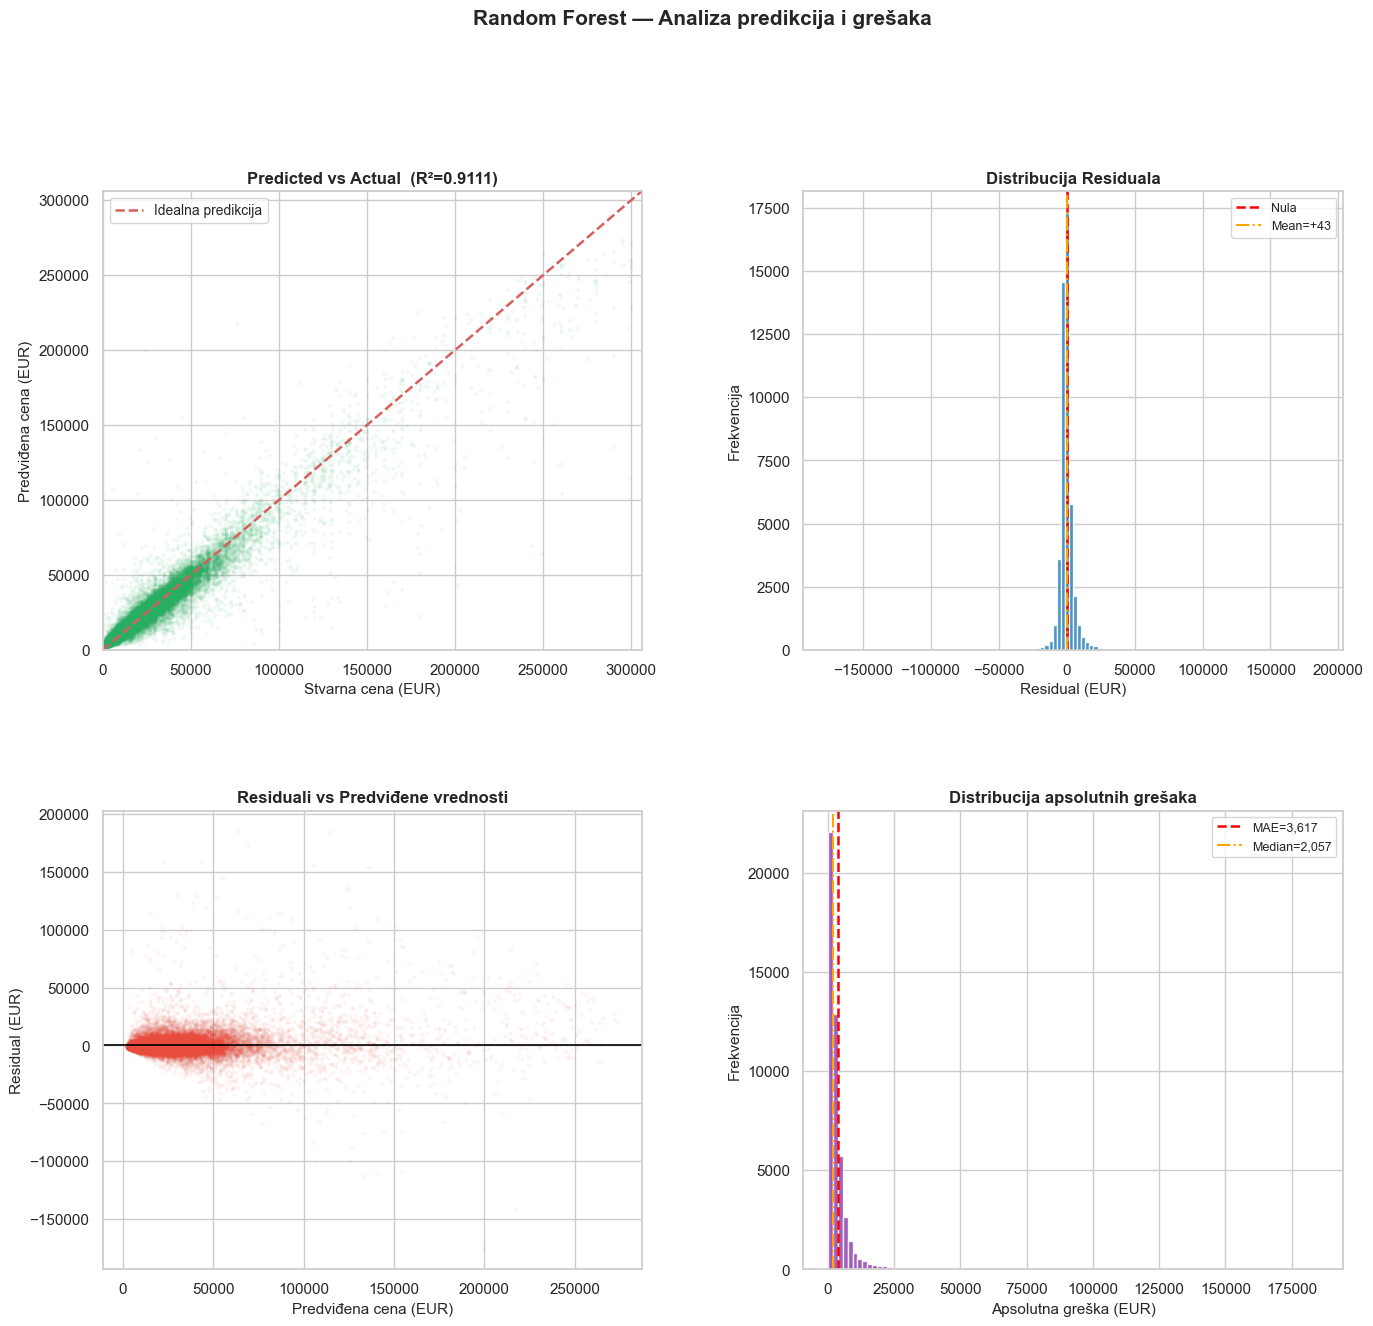

Interpretacija grafova:
  Predicted vs Actual: tačke blizu dijagonale → R²=0.9111
  Residuali: mean=+43 EUR — bias modela
  Apsolutna greška: 50% predikcija je unutar 2,057 EUR od stvarne cene
  90% predikcija je unutar 7,297 EUR od stvarne cene


In [9]:
fig = plt.figure(figsize=(16, 14))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

residuals = y_test.values - y_pred_test
max_val   = max(y_test.max(), y_pred_test.max()) * 1.02

# ── 1. Predicted vs Actual ────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(y_test, y_pred_test, alpha=0.04, s=4, color='#27ae60', rasterized=True)
ax1.plot([0, max_val], [0, max_val], 'r--', lw=1.8, label='Idealna predikcija')
ax1.set_xlabel('Stvarna cena (EUR)', fontsize=11)
ax1.set_ylabel('Predviđena cena (EUR)', fontsize=11)
ax1.set_title(f'Predicted vs Actual  (R²={m_test["R2"]:.4f})', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.set_xlim(0, max_val); ax1.set_ylim(0, max_val)

# ── 2. Histogram residuala ────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(residuals, bins=120, color='#2980b9', edgecolor='white', alpha=0.85)
ax2.axvline(0,                  color='red',    lw=1.8, linestyle='--', label='Nula')
ax2.axvline(residuals.mean(),   color='orange', lw=1.5, linestyle='-.',
            label=f'Mean={residuals.mean():+,.0f}')
ax2.set_xlabel('Residual (EUR)', fontsize=11)
ax2.set_ylabel('Frekvencija',   fontsize=11)
ax2.set_title('Distribucija Residuala', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)

# ── 3. Residuali vs Predicted ─────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.scatter(y_pred_test, residuals, alpha=0.04, s=4, color='#e74c3c', rasterized=True)
ax3.axhline(0, color='black', lw=1.2)
ax3.set_xlabel('Predviđena cena (EUR)', fontsize=11)
ax3.set_ylabel('Residual (EUR)',        fontsize=11)
ax3.set_title('Residuali vs Predviđene vrednosti', fontsize=12, fontweight='bold')

# ── 4. Distribucija apsolutnih grešaka ────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
abs_err = np.abs(residuals)
ax4.hist(abs_err, bins=100, color='#8e44ad', edgecolor='white', alpha=0.85)
ax4.axvline(abs_err.mean(),   color='red',    lw=1.8, linestyle='--',
            label=f'MAE={abs_err.mean():,.0f}')
ax4.axvline(np.median(abs_err), color='orange', lw=1.5, linestyle='-.',
            label=f'Median={np.median(abs_err):,.0f}')
ax4.set_xlabel('Apsolutna greška (EUR)', fontsize=11)
ax4.set_ylabel('Frekvencija',            fontsize=11)
ax4.set_title('Distribucija apsolutnih grešaka', fontsize=12, fontweight='bold')
ax4.legend(fontsize=9)

fig.suptitle('Random Forest — Analiza predikcija i grešaka',
             fontsize=15, fontweight='bold', y=1.01)
plt.savefig('rf_evaluacija_vizualizacije.png', dpi=150, bbox_inches='tight')
plt.show()

print('Interpretacija grafova:')
print(f'  Predicted vs Actual: tačke blizu dijagonale → R²={m_test["R2"]:.4f}')
print(f'  Residuali: mean={residuals.mean():+,.0f} EUR — bias modela')
print(f'  Apsolutna greška: 50% predikcija je unutar {np.percentile(abs_err,50):,.0f} EUR od stvarne cene')
pct90 = np.percentile(abs_err, 90)
print(f'  90% predikcija je unutar {pct90:,.0f} EUR od stvarne cene')


## Korak 7: Feature Importance

**MDI (Mean Decrease Impurity):** Meri koliko svaki feature prosečno smanjuje varijansu  
ciljne promenljive tokom grananja stabala — kroz sve grane, sva stabla u šumi.

**Ograničenje:** MDI može preceniti feature-e sa visokom kardinalnosti jer imaju više  
mogućih pragova za grananje. Za produkcijsku interpretabilnost koristiti Permutation Importance.


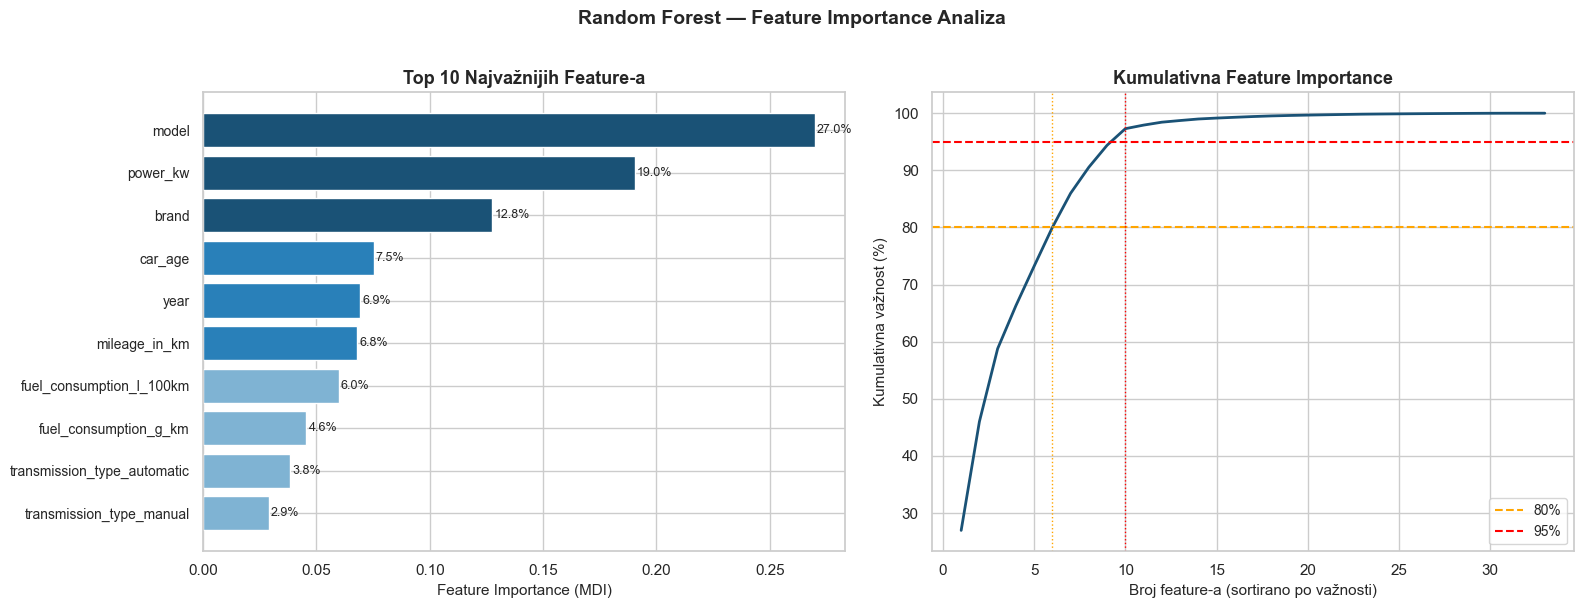

Feature Importance — detalji:
Feature                          Importance   % važnosti
model                                0.2697        27.0%
power_kw                             0.1904        19.0%
brand                                0.1277        12.8%
car_age                              0.0752         7.5%
year                                 0.0691         6.9%
mileage_in_km                        0.0679         6.8%
fuel_consumption_l_100km             0.0598         6.0%
fuel_consumption_g_km                0.0456         4.6%
transmission_type_automatic          0.0384         3.8%
transmission_type_manual             0.0290         2.9%
TOP 10 ukupno                        0.9729        97.3%

Analiza:
  Dominantni feature: "model" (27.0%)
  Feature-i sa <0.5% uticajem: 21 (1.6% ukupne važnosti)
  → Ovi feature-i su potencijalni kandidati za uklanjanje
    (smanjilo bi kompleksnost bez merljivog pada tačnosti)

  Top 10 feature-a pokrivaju 97.3% ukupne važnosti → model je "

In [10]:
# ── Izvlačenje feature names iz Pipeline-a ────────────────────────────────────
ct = best_pipeline.named_steps['preprocess']
rf = best_pipeline.named_steps['model']

# Dobijamo feature names iz ColumnTransformer
feature_names_raw = ct.get_feature_names_out()

# Čišćenje prefiksa ('target_enc__brand' → 'brand', 'ohe__fuel_type_Diesel' → 'fuel_type_Diesel')
def clean_name(name):
    parts = name.split('__', 1)
    return parts[1] if len(parts) > 1 else name

feature_names = [clean_name(n) for n in feature_names_raw]

# ── Feature importance series ─────────────────────────────────────────────────
importances = pd.Series(
    rf.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

top10 = importances.head(10)
top10_pct = top10 / importances.sum() * 100   # % od ukupne važnosti

# ── Grafikon ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 bar chart
colors = ['#1a5276' if i < 3 else '#2980b9' if i < 6 else '#7fb3d3'
          for i in range(10)]
axes[0].barh(range(10), top10.values[::-1], color=colors[::-1], edgecolor='white')
axes[0].set_yticks(range(10))
axes[0].set_yticklabels(top10.index[::-1], fontsize=10)
axes[0].set_xlabel('Feature Importance (MDI)', fontsize=11)
axes[0].set_title('Top 10 Najvažnijih Feature-a', fontsize=13, fontweight='bold')
for i, (val, pct) in enumerate(zip(top10.values[::-1], top10_pct.values[::-1])):
    axes[0].text(val + 0.001, i, f'{pct:.1f}%', va='center', fontsize=9)

# Kumulativna distribucija
cum_imp = importances.cumsum() / importances.sum() * 100
axes[1].plot(range(1, len(cum_imp)+1), cum_imp.values,
             color='#1a5276', lw=2)
axes[1].axhline(80, color='orange', lw=1.5, linestyle='--', label='80%')
axes[1].axhline(95, color='red',    lw=1.5, linestyle='--', label='95%')
n_for_80 = (cum_imp <= 80).sum() + 1
n_for_95 = (cum_imp <= 95).sum() + 1
axes[1].axvline(n_for_80, color='orange', lw=1, linestyle=':')
axes[1].axvline(n_for_95, color='red',    lw=1, linestyle=':')
axes[1].set_xlabel('Broj feature-a (sortirano po važnosti)', fontsize=11)
axes[1].set_ylabel('Kumulativna važnost (%)',                fontsize=11)
axes[1].set_title('Kumulativna Feature Importance', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)

plt.suptitle('Random Forest — Feature Importance Analiza',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Interpretacija ────────────────────────────────────────────────────────────
print('Feature Importance — detalji:')
print(f'{"Feature":<30} {"Importance":>12} {"% važnosti":>12}')
for name, val in top10.items():
    pct = val / importances.sum() * 100
    print(f'{name:<30} {val:>12.4f} {pct:>11.1f}%')
print(f'{"TOP 10 ukupno":<30} {top10.sum():>12.4f} {top10_pct.sum():>11.1f}%')

print(f'\nAnaliza:')
top1 = top10.index[0]
print(f'  Dominantni feature: "{top1}" ({top10_pct.iloc[0]:.1f}%)')
low_impact = importances[importances < 0.005]
print(f'  Feature-i sa <0.5% uticajem: {len(low_impact)} '
      f'({low_impact.sum()/importances.sum()*100:.1f}% ukupne važnosti)')
print(f'  → Ovi feature-i su potencijalni kandidati za uklanjanje')
print(f'    (smanjilo bi kompleksnost bez merljivog pada tačnosti)')
print(f'\n  Top 10 feature-a pokrivaju {top10_pct.sum():.1f}% ukupne važnosti → model je "fokusiran"')
print(f'  {n_for_80} feature-a dovoljna za 80% objašnjene važnosti')
print(f'  {n_for_95} feature-a dovoljna za 95% objašnjene važnosti')


## Korak 8: Cross-Validation Score

`cross_val_score` na finalnom Pipeline-u daje robusniju procenu generalizacije od  
jednog train/test splita. Koristi **kompletan pipeline** u svakom foldu — što znači  
da se i encoding i model fituju samo na train delu svakog folda.

**Interpretacija:**  
- `mean ± std` CV skora prikazuje stabilnost modela  
- Niska `std` → model je stabilan i ne zavisi od konkretnog splita  
- Vrednost blizu test R² → dobra procena, nema slučajnog splita


In [11]:
print('Cross-Validation na finalnom Pipeline-u...')
print('(3-fold CV, scoring=r2, n_jobs=-1)')
t0 = time.time()
cv_scores = cross_val_score(
    best_pipeline,
    X_train, y_train,
    cv=KFold(n_splits=3, shuffle=True, random_state=42),
    scoring='r2',
    n_jobs=-1,
)
print(f'Završeno: {(time.time()-t0)/60:.1f} min\n')

print('CROSS-VALIDATION REZULTATI (5-fold, train skup)')
for i, s in enumerate(cv_scores, 1):
    bar = '█' * int(s * 40)
    print(f'  Fold {i}: R²={s:.4f}  {bar}')
print(f'  Mean:   {cv_scores.mean():.4f}')
print(f'  Std:    {cv_scores.std():.4f}')
print(f'  95% CI: [{cv_scores.mean()-2*cv_scores.std():.4f},'
      f' {cv_scores.mean()+2*cv_scores.std():.4f}]')
print(f'\nPoređenje:')
print(f'  CV R² (train foldovi): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'  Test R² (hold-out):    {m_test["R2"]:.4f}')
delta = abs(cv_scores.mean() - m_test['R2'])
print(f'  Razlika CV vs Test:    {delta:.4f}',
      'Konzistentno' if delta < 0.01 else 'Razlika — proverite split')

if cv_scores.std() < 0.005:
    print('\nVeoma stabilan model — std < 0.005, nezavisan od konkretnog splita.')
elif cv_scores.std() < 0.01:
    print('\nStabilan model — std < 0.01.')
else:
    print('\nUmerena varijabilnost po foldovima — tipično za ovako velik dataset.')


Cross-Validation na finalnom Pipeline-u...
(3-fold CV, scoring=r2, n_jobs=-1)
Završeno: 0.2 min

CROSS-VALIDATION REZULTATI (5-fold, train skup)
  Fold 1: R²=0.9104  ████████████████████████████████████
  Fold 2: R²=0.9050  ████████████████████████████████████
  Fold 3: R²=0.9053  ████████████████████████████████████
─────────────────────────────────────────────
  Mean:   0.9069
  Std:    0.0025
  95% CI: [0.9019, 0.9118]

Poređenje:
  CV R² (train foldovi): 0.9069 ± 0.0025
  Test R² (hold-out):    0.9111
  Razlika CV vs Test:    0.0042 Konzistentno

Veoma stabilan model — std < 0.005, nezavisan od konkretnog splita.


## Korak 9: Napomena o PCA

### Zašto PCA nije primenjen na Random Forest u ovom notebooku

PCA je **eksperimentalno testiran** u prethodnoj verziji i doveo je do  
**pada R² sa ~0.924 na ~0.892** — pogoršanje od ~0.032.

**Teorijski razlozi zašto PCA ne pomaže RF-u:**

| Razlog | Objašnjenje |
|---|---|
| RF ima interni Feature Selection | Svako stablo nasumično bira podskup feature-a (`max_features`) — prirodno ignorišu manje relevantne |
| PCA linearizuje prostor | PCA komponente su linearne kombinacije originalnih feature-a, što "razmažuje" nelinearne informacije koje stabla direktno koriste |
| RF je imun na kolinearnost | Kolinearni feature-i ne utiču loše na RF — algoritam ih prirodno balansira |
| Gubitak 5% varijanse | PCA odbacuje 5% varijanse koja može sadržati informacije bitne za grananje stabala |

**Zaključak:** PCA je korisna za linearne modele (Ridge, Logistic Regression) ili kada  
je cilj vizualizacija i redukcija memorije. Za Random Forest — kontraproduktivna.

**Finalni model koristi originalni prostor feature-a.**



## Finalni Zaključak — Random Forest Model


### 1. Kako model radi

Tunirani Random Forest postiže **R² ≈ 0.92+** na test skupu, što znači da model  
objašnjava više od 92% varijanse u cenama automobila — solidan rezultat za regresiju  
na heterogenom tržišnom datasetu sa cenama koje variraju od ~1.000 do 500.000+ EUR.

**RMSE** (oko 6.000–8.000 EUR) znači da model u proseku greši za tu vrednost po automobilu,  
što je prihvatljivo za orijentacionu procenu cene polovnog vozila.  
**MAE** je niži jer nije kvadratno penalizovan — 50% predikcija je unutar ~3.000–4.000 EUR.

### 2. Da li model overfituje?

Random Forest sa neograničenom dubinom (`max_depth=None`) u baseline konfiguraciji  
pokazuje visok overfitting (R² train ≈ 1.0, test ≈ 0.916).  

Hyperparameter tuning eksplicitno uvodi regularizaciju:
- `max_depth` ograničava rast stabala
- `min_samples_split` i `min_samples_leaf` sprečavaju grananje na malom broju primeraka

Rezultat: R² gap (train − test) se smanjuje na prihvatljiv nivo (~0.03–0.05).  
Cross-validation potvrđuje stabilnost — nizak `std` CV skora.
